## **Modelo 1: Clustering K-Means**

## Carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## Revisión de la Base Final 2

In [ ]:
BaseFinal2 = pd.read_csv("../processed/BaseFinal2_clean.csv")

# Comprobamos valores nulos
print("\nValores nulos por columna:")
print(BaseFinal2.isnull().sum())

print("Dimensiones:", BaseFinal2.shape)
display(BaseFinal2)
print(BaseFinal2.info())



Valores nulos por columna:
ccaa                      0
pct_centro_primaria       0
pct_centro_secundaria     0
gasto_reglado_medio       0
eso_concertado            0
eso_privado               0
eso_publico               0
pct_bach_privado          0
pct_bach_publico          0
pct_fpbasica_publico      0
pct_fpbasica_privado      0
pct_fpmedio_publico       0
pct_fpmedio_privado       0
pct_fpsuperior_publico    0
pct_fpsuperior_privado    0
renta_per_capita          0
dtype: int64
Dimensiones: (19, 16)


,ccaa,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita
0,Andalucia,14.285714,85.714286,1128,92.5,93.2,85.9,95.3,87.4,74.870056,25.129944,61.138573,38.861427,59.363410,40.636590,11719
1,Aragon,66.284404,33.715596,9700,90.5,91.1,87.1,96.9,89.1,69.138756,30.861244,64.055438,35.944562,58.560360,41.439640,14810
2,Asturias,66.871166,33.128834,8950,91.6,92.1,86.6,95.5,85.2,67.567568,32.432432,67.046688,32.953312,74.561061,25.438939,15432
3,Canarias,70.656371,29.343629,1446,95.3,95.9,85.0,96.3,85.6,93.813273,6.186727,91.192239,8.807761,86.934673,13.065327,12177
4,Cantabria,66.976744,33.023256,6800,94.4,94.4,91.3,94.7,89.9,59.292035,40.707965,66.885677,33.114323,70.578134,29.421866,14162
5,Castilla La Mancha,71.058315,28.941685,8610,90.4,91.2,83.9,95.6,87.1,88.213491,11.786509,76.640121,23.359879,85.384081,14.615919,11913
6,Castilla y Leon,68.000000,32.000000,1121,92.6,92.6,85.2,95.4,85.1,64.721254,35.278746,66.226415,33.773585,71.654212,28.345788,14124
7,Cataluña,18.229557,81.770443,1945,93.6,93.8,85.6,96.2,89.4,100.000000,0.000000,69.136812,30.863188,62.147622,37.852378,15830
8,Ceuta,70.833333,29.166667,3980,93.2,93.2,79.0,95.7,74.7,91.666667,8.333333,100.000000,0.000000,100.000000,0.000000,13421
9,Comunidad Valenciana,17.456022,82.543978,1437,92.3,92.7,82.7,94.6,86.1,88.438481,11.561519,66.682762,33.317238,68.097416,31.902584,12805


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ccaa                    19 non-null     str    
 1   pct_centro_primaria     19 non-null     float64
 2   pct_centro_secundaria   19 non-null     float64
 3   gasto_reglado_medio     19 non-null     int64  
 4   eso_concertado          19 non-null     float64
 5   eso_privado             19 non-null     float64
 6   eso_publico             19 non-null     float64
 7   pct_bach_privado        19 non-null     float64
 8   pct_bach_publico        19 non-null     float64
 9   pct_fpbasica_publico    19 non-null     float64
 10  pct_fpbasica_privado    19 non-null     float64
 11  pct_fpmedio_publico     19 non-null     float64
 12  pct_fpmedio_privado     19 non-null     float64
 13  pct_fpsuperior_publico  19 non-null     float64
 14  pct_fpsuperior_privado  19 non-null     float64
 15  re

## Selección de variables y estandarización de las variables


Número de variables que entran en el modelo: 15

Variables seleccionadas para K-Means:
['pct_centro_primaria', 'pct_centro_secundaria', 'gasto_reglado_medio', 'eso_concertado', 'eso_privado', 'eso_publico', 'pct_bach_privado', 'pct_bach_publico', 'pct_fpbasica_publico', 'pct_fpbasica_privado', 'pct_fpmedio_publico', 'pct_fpmedio_privado', 'pct_fpsuperior_publico', 'pct_fpsuperior_privado', 'renta_per_capita']


,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita
0,-2.377543,2.377543,-0.883798,-0.214774,-0.059739,0.074398,0.232448,0.252149,-0.115267,0.115267,-0.994215,0.994215,-1.154657,1.154657,-1.206131
1,0.370276,-0.370276,1.726266,-1.274698,-1.314257,0.420576,1.083825,0.709700,-0.443500,0.443500,-0.755690,0.755690,-1.217514,1.217514,0.428344
2,0.401283,-0.401283,1.497900,-0.691740,-0.716868,0.276335,0.338870,-0.339976,-0.533482,0.533482,-0.511082,0.511082,0.034924,-0.034924,0.757248
3,0.601308,-0.601308,-0.786971,1.269119,1.553213,-0.185235,0.764559,-0.232317,0.969614,-0.969614,1.463407,-1.463407,1.003456,-1.003456,-0.963948
4,0.406862,-0.406862,0.843253,0.792153,0.657129,1.632197,-0.086818,0.925018,-1.007423,1.007423,-0.524249,0.524249,-0.276836,0.276836,0.085691
5,0.622549,-0.622549,1.394375,-1.327694,-1.254519,-0.502565,0.392081,0.171405,0.648913,-0.648913,0.273415,-0.273415,0.882085,-0.882085,-1.103547
6,0.460935,-0.460935,-0.885929,-0.161778,-0.418173,-0.127539,0.285659,-0.366891,-0.696491,0.696491,-0.578160,0.578160,-0.192607,0.192607,0.065597
7,-2.169134,2.169134,-0.635032,0.368184,0.298695,-0.012147,0.711348,0.790444,1.323929,-1.323929,-0.340164,0.340164,-0.936725,0.936725,0.967705
8,0.610660,-0.610660,-0.015401,0.156199,-0.059739,-1.916124,0.445293,-3.166027,0.846677,-0.846677,2.183657,-2.183657,2.026131,-2.026131,-0.306139
9,-2.210011,2.210011,-0.789711,-0.320766,-0.358434,-0.848743,-0.140029,-0.097743,0.661799,-0.661799,-0.540842,0.540842,-0.471011,0.471011,-0.631871


,mean,std
pct_centro_primaria,-7.304099e-17,1.027402
pct_centro_secundaria,2.249662e-16,1.027402
gasto_reglado_medio,-8.180591e-17,1.027402
eso_concertado,-7.829994e-16,1.027402
eso_privado,1.343954e-15,1.027402
eso_publico,-1.963342e-15,1.027402
pct_bach_privado,-7.958546e-15,1.027402
pct_bach_publico,-2.816461e-15,1.027402
pct_fpbasica_publico,-3.739699e-16,1.027402
pct_fpbasica_privado,-1.402387e-16,1.027402


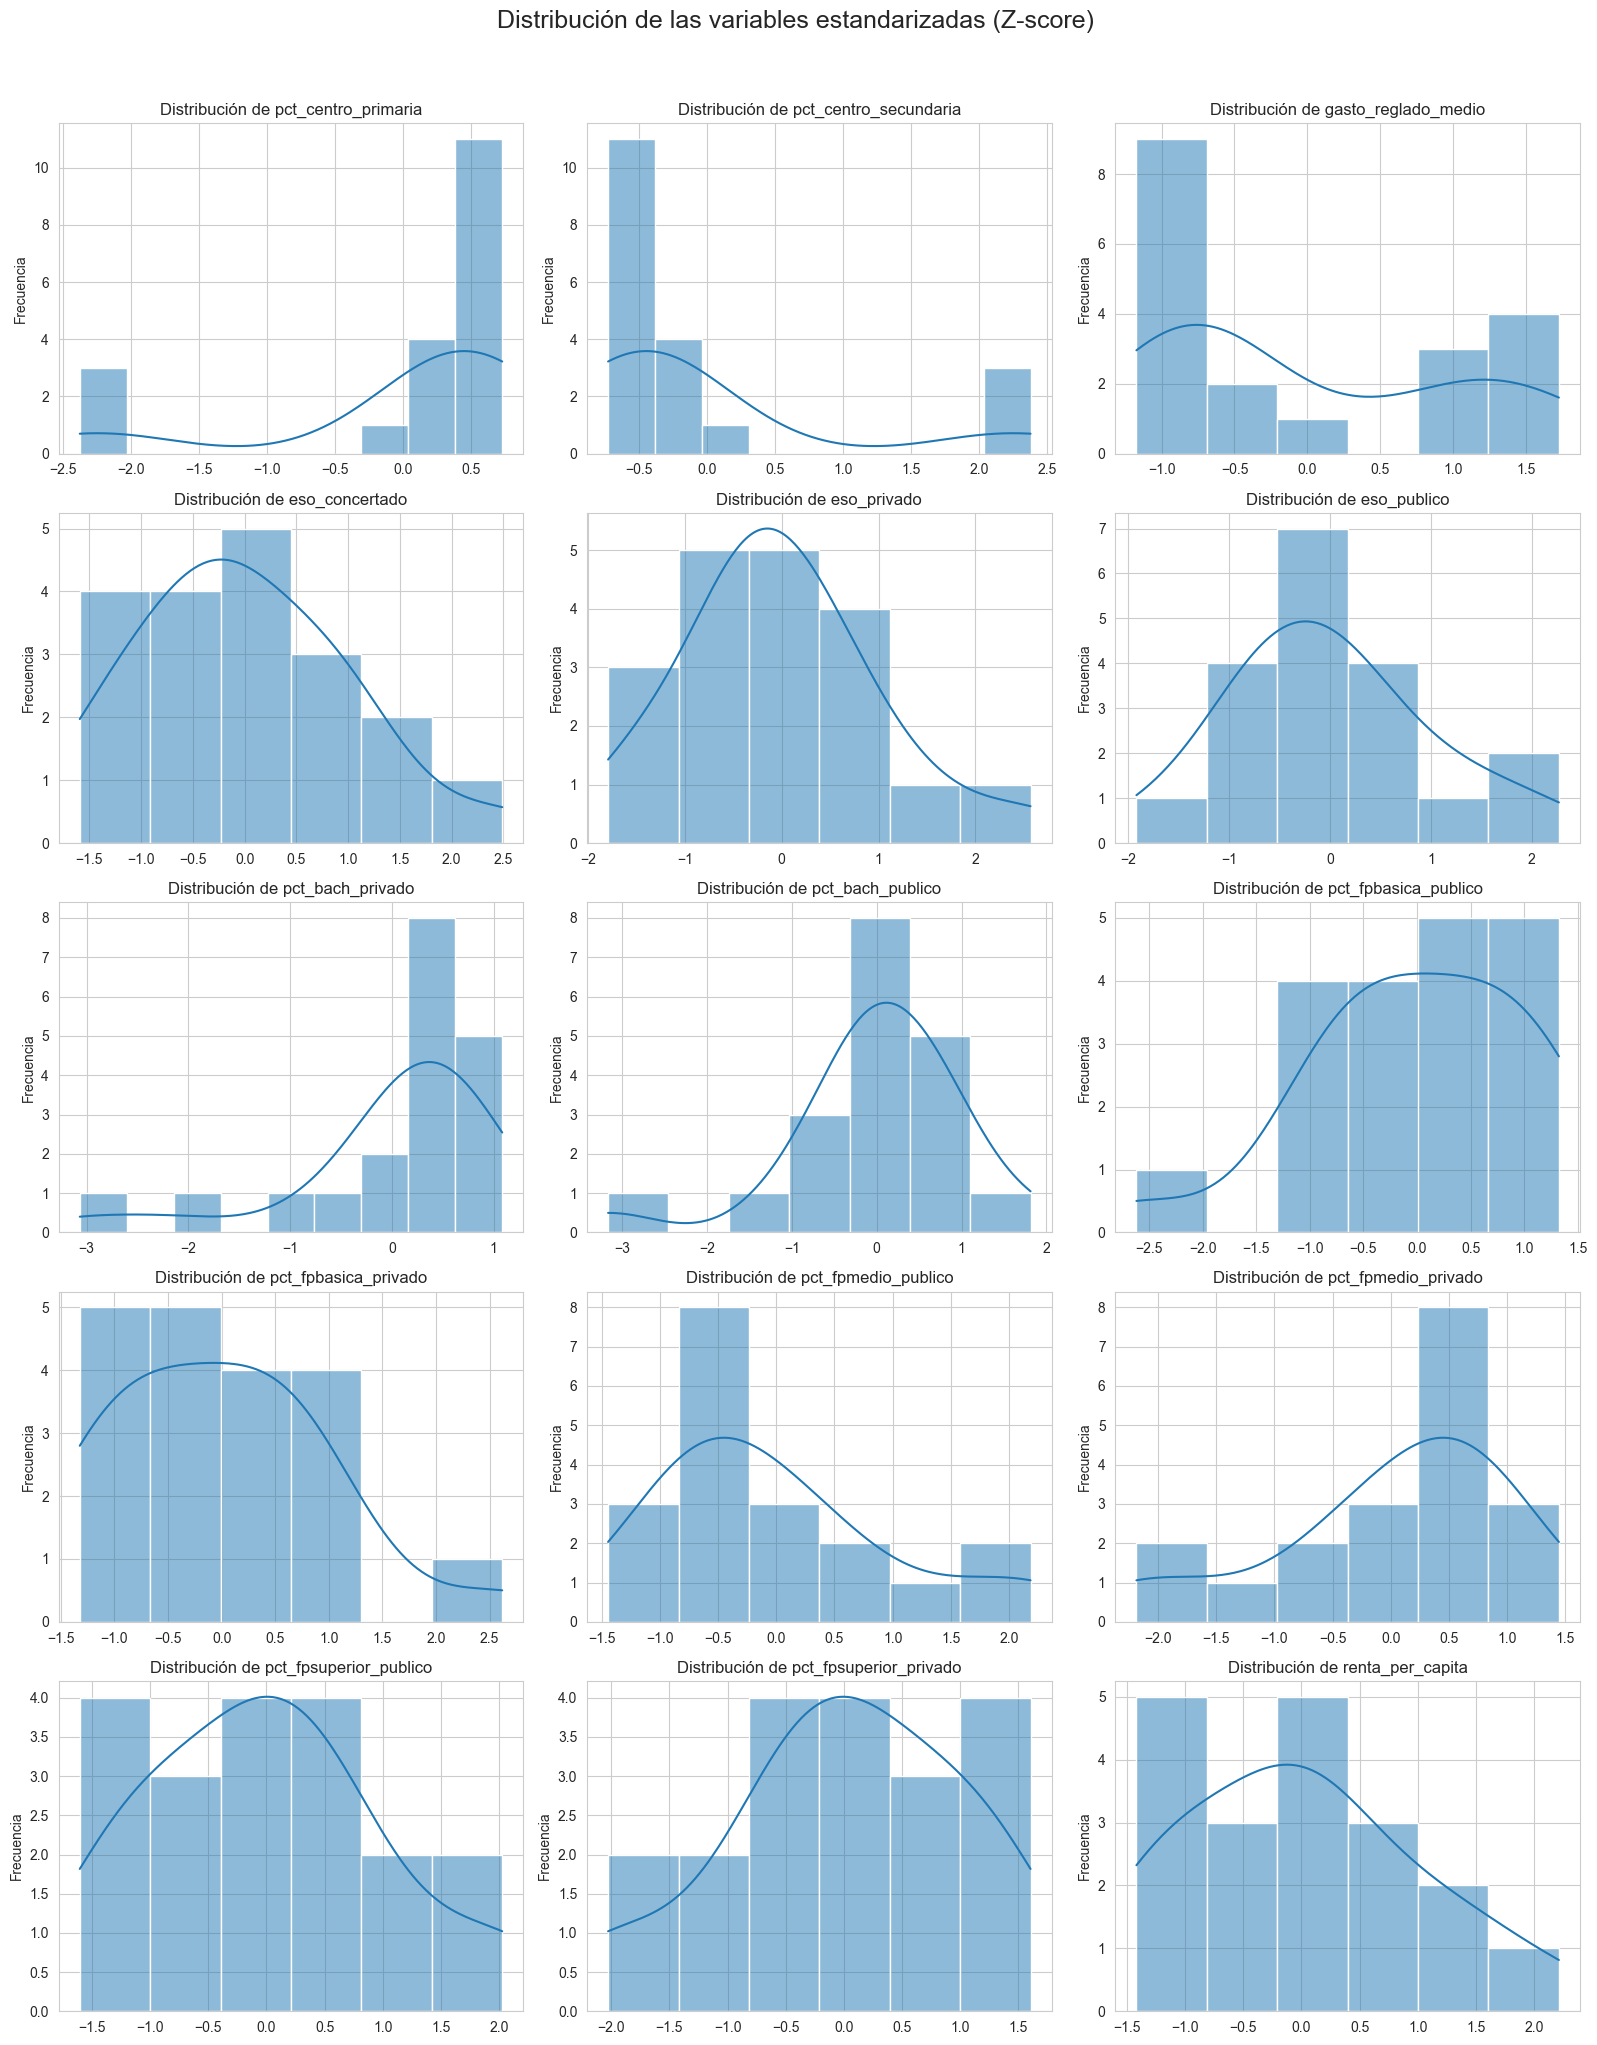

In [ ]:
# Creamos una carpeta para guardar los resultados visuales. 

carpeta_graficos = "graficos_clustering"
os.makedirs(carpeta_graficos, exist_ok=True)

# Separamos la columna identificadora
ccaa = BaseFinal2["ccaa"]

# Creamos la matriz de variables para clustering
X = BaseFinal2.drop(columns=["ccaa"])

print("\nNúmero de variables que entran en el modelo:", X.shape[1])
print("\nVariables seleccionadas para K-Means:")
print(X.columns.tolist())

# Estandarizamos las variables mediante el método z-score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos el resultado a DataFrame para que sea más fácil visualizarlo

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled)

# Comprobamos la estandarización de las variables

resumen_escalado = X_scaled.agg(["mean", "std"]).T
display(resumen_escalado)

# Visualizamos las variables estandarizadas 

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(X_scaled.columns):
    sns.histplot(X_scaled[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribución de las variables estandarizadas (Z-score)", fontsize=18, y=1.02)
plt.savefig('graficos_clustering/00_distribucion_estandarizada.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

## Método del codo - Elbow Method

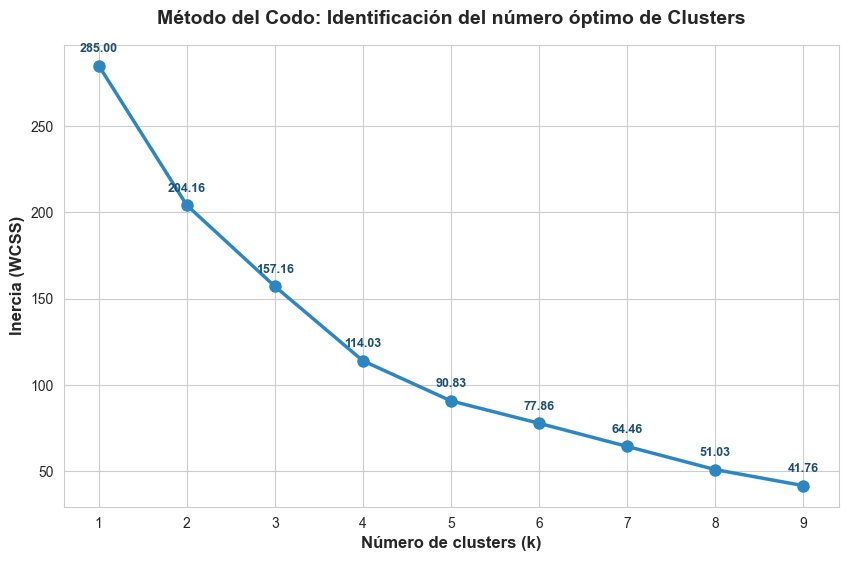

In [ ]:
# Para determinar el número óptimo de clusters empleamos el método del codo.
# 1. Calculamos las distancias cuadráticas(inercias) para los distintos valores de K

inercias = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)


# 2. Visualizamos el gráfico del codo para poder tomar una decisión

plt.figure(figsize=(10, 6))

plt.plot(k_values, inercias, marker="o", linestyle="-", color="#2E86C1", linewidth=2.5, markersize=8)

plt.xlabel("Número de clusters (k)", fontsize=12, fontweight='bold')
plt.ylabel("Inercia (WCSS)", fontsize=12, fontweight='bold')
plt.title("Método del Codo: Identificación del número óptimo de Clusters", fontsize=14, fontweight='bold', pad=15)

# Marcamos los puntos con las anotaciones.

for i, txt in enumerate(inercias):
    plt.annotate(f'{txt:.2f}', (k_values[i], inercias[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9,
                 fontweight='bold',
                 color="#1B4F72")

plt.savefig('graficos_clustering/02_metodo_codo.png', bbox_inches='tight', dpi=300)
plt.show()

# Al visualizar el método del codo, se puede observar que con K=3 o K=4 ya se captura una parte
# importante de la estructura de los datos. Es el punto donde la reducción de la inercia
# empieza a estabilizarse.


## Silhouette

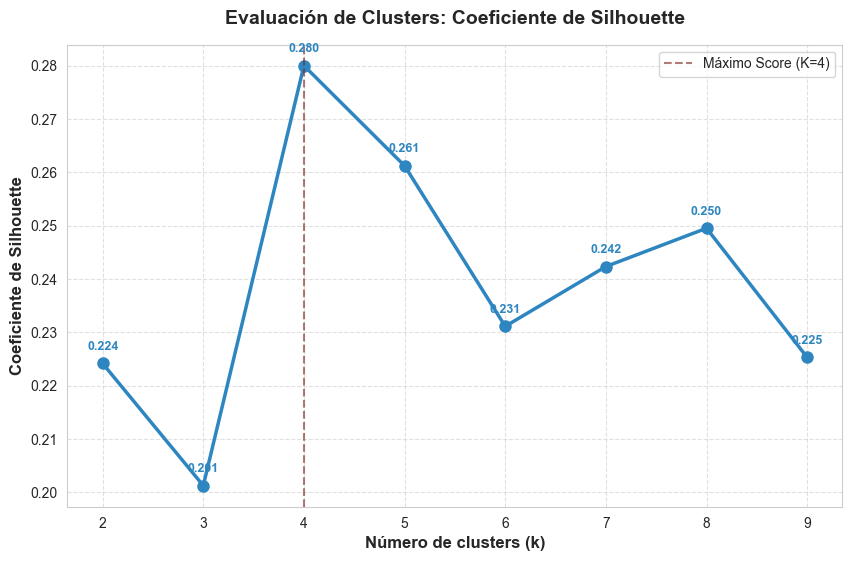

In [ ]:
# Aplicamos el coeficiente de Silhouette al modelo

silhouette_scores = []
k_values = range(2, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Visualizamos los resultados gráficamente

plt.figure(figsize=(10, 6))

plt.plot(k_values, silhouette_scores, marker="o", linestyle="-", color="#2E86C1", linewidth=2.5, markersize=8)

plt.xlabel("Número de clusters (k)", fontsize=12, fontweight='bold')
plt.ylabel("Coeficiente de Silhouette", fontsize=12, fontweight='bold')
plt.title("Evaluación de Clusters: Coeficiente de Silhouette", fontsize=14, fontweight='bold', pad=15)

# Marcamos los puntos con las anotaciones.

for i, txt in enumerate(silhouette_scores):
    plt.annotate(f'{txt:.3f}', (k_values[i], silhouette_scores[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', 
                 fontsize=9,
                 fontweight='bold',
                 color="#2E86C1") 

plt.axvline(x=4, color="#7B241C", linestyle='--', alpha=0.6, label='Máximo Score (K=4)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('graficos_clustering/03_coeficiente_silhouette.png', bbox_inches='tight', dpi=300)
plt.show()

# Con el método del codo dudabamos entre 3 o 4 clusters, pero el coeficinete de Silhouette nos muestra que el valor máximo se encuentra en K=4.
# Por tanto, el modelo final de K-Means será con K=4.

## Modelo Final K-Means (K=4)

,ccaa,cluster_kmeans
0,Andalucia,0
1,Aragon,1
2,Asturias,1
3,Canarias,3
4,Cantabria,1
5,Castilla La Mancha,2
6,Castilla y Leon,1
7,Cataluña,0
8,Ceuta,3
9,Comunidad Valenciana,0


Número de comunidades por cluster:
cluster_kmeans
0    3
1    9
2    4
3    3
Name: count, dtype: int64
Valores medios por cluster:


,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita,cluster_jerarquico
cluster_kmeans,,,,,,,,,,,,,,,,
0,16.657098,83.342902,1503.333333,92.800000,93.233333,84.733333,95.366667,87.633333,87.769513,12.230487,65.652716,34.347284,63.202816,36.797184,13451.333333,2.0
1,64.491660,35.508340,3577.222222,93.000000,93.311111,87.611111,95.577778,87.822222,62.487070,37.512930,67.081504,32.918496,68.670544,31.329456,15273.777778,0.0
2,71.550885,28.449115,7895.000000,90.925000,91.625000,84.600000,92.700000,85.525000,87.400028,12.599972,75.187820,24.812180,78.401202,21.598798,12182.250000,3.0
3,69.890507,30.109493,2765.333333,95.366667,95.566667,82.033333,95.100000,82.466667,95.159980,4.840020,97.064080,2.935920,95.644891,4.355109,13150.666667,1.0


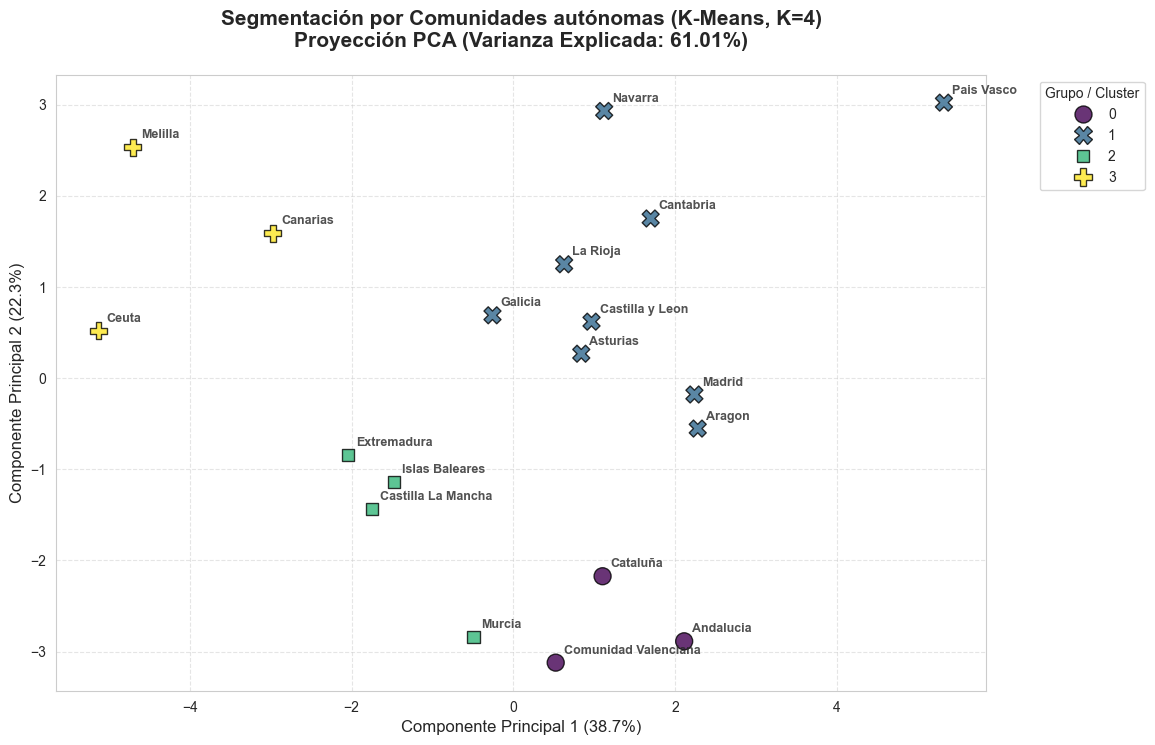

In [ ]:
# Entrenamos el modelo final con K=4

kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
BaseFinal2["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

# Obtenemos los resultados del modelo

display(BaseFinal2[["ccaa", "cluster_kmeans"]])

# Sacamos el número de CCAA por cluster

cluster_sizes = BaseFinal2["cluster_kmeans"].value_counts().sort_index()

print("Número de comunidades por cluster:")
print(cluster_sizes)

# Calculamos los valores medios por cluster

X_cluster = BaseFinal2.drop(columns=["ccaa"])

cluster_summary = X_cluster.groupby(BaseFinal2["cluster_kmeans"]).mean()
print("Valores medios por cluster:")
display(cluster_summary)

# Visualizamos el modelo gráficamente con PCA
# 1. Reducimos dimensiones porque tenemos muchas variables para que se pueda representar correctamente.

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Guardamos el % de varianza

var_expl = pca.explained_variance_ratio_
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["ccaa"] = BaseFinal2["ccaa"].values
df_pca["cluster"] = BaseFinal2["cluster_kmeans"].values

# 3. Obtenemos el gráfico de clusters.

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

scatter = sns.scatterplot(
    data=df_pca, 
    x="PC1", 
    y="PC2", 
    hue="cluster", 
    palette="viridis", 
    s=150, 
    style="cluster",
    edgecolor="black",
    alpha=0.8
)

# Añadimos las etiquetas de las CCAA

for i in range(df_pca.shape[0]):
    plt.text(
        df_pca.PC1[i] + 0.1, 
        df_pca.PC2[i] + 0.1, 
        df_pca.ccaa[i], 
        fontsize=9, 
        fontweight='semibold',
        alpha=0.8
    )

# Títulos con información técnica (Varianza explicada)

plt.title(f"Segmentación por Comunidades autónomas (K-Means, K=4)\nProyección PCA (Varianza Explicada: {var_expl.sum():.2%})", 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Componente Principal 1 ({var_expl[0]:.1%})", fontsize=12)
plt.ylabel(f"Componente Principal 2 ({var_expl[1]:.1%})", fontsize=12)
plt.legend(title="Grupo / Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('graficos_clustering/04_mapa_clusters_pca.png', bbox_inches='tight', dpi=300)
plt.show()



## **Modelo 2: Clustering Jerárquico**

# Carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
import os
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Base Final 2

In [ ]:
# Separamos las variables numéricas de las CCAA

ccaa = BaseFinal2["ccaa"]
X = BaseFinal2.drop(columns=["ccaa"])

# Estandarizamos las variables

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dimensiones de X_scaled:", X_scaled.shape)


Dimensiones de X_scaled: (19, 16)


# Elección del método de enlace

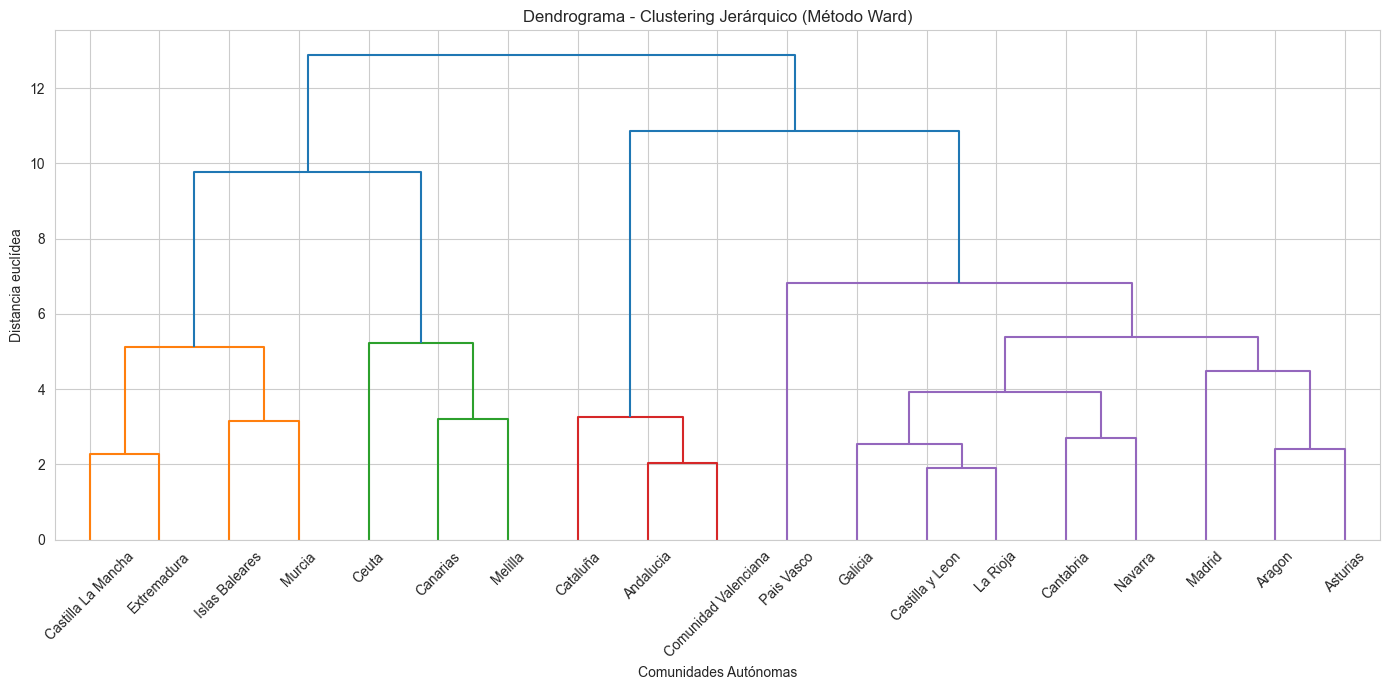

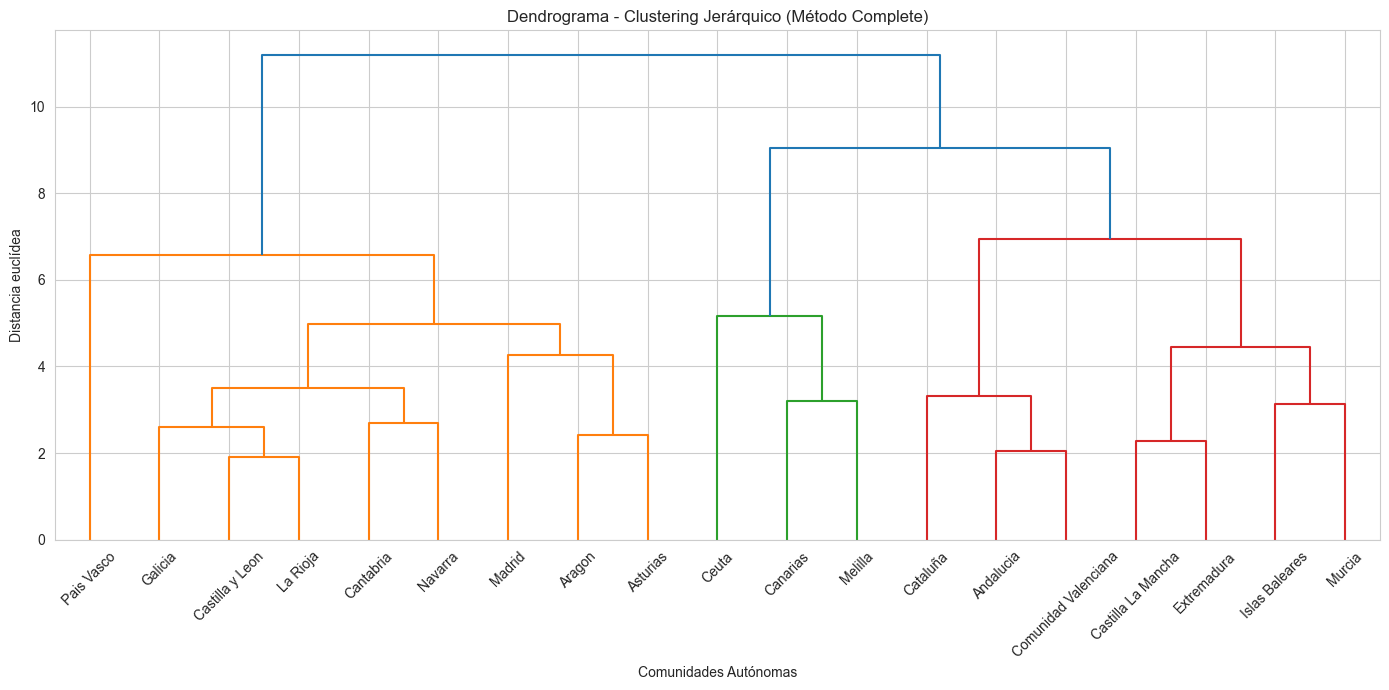

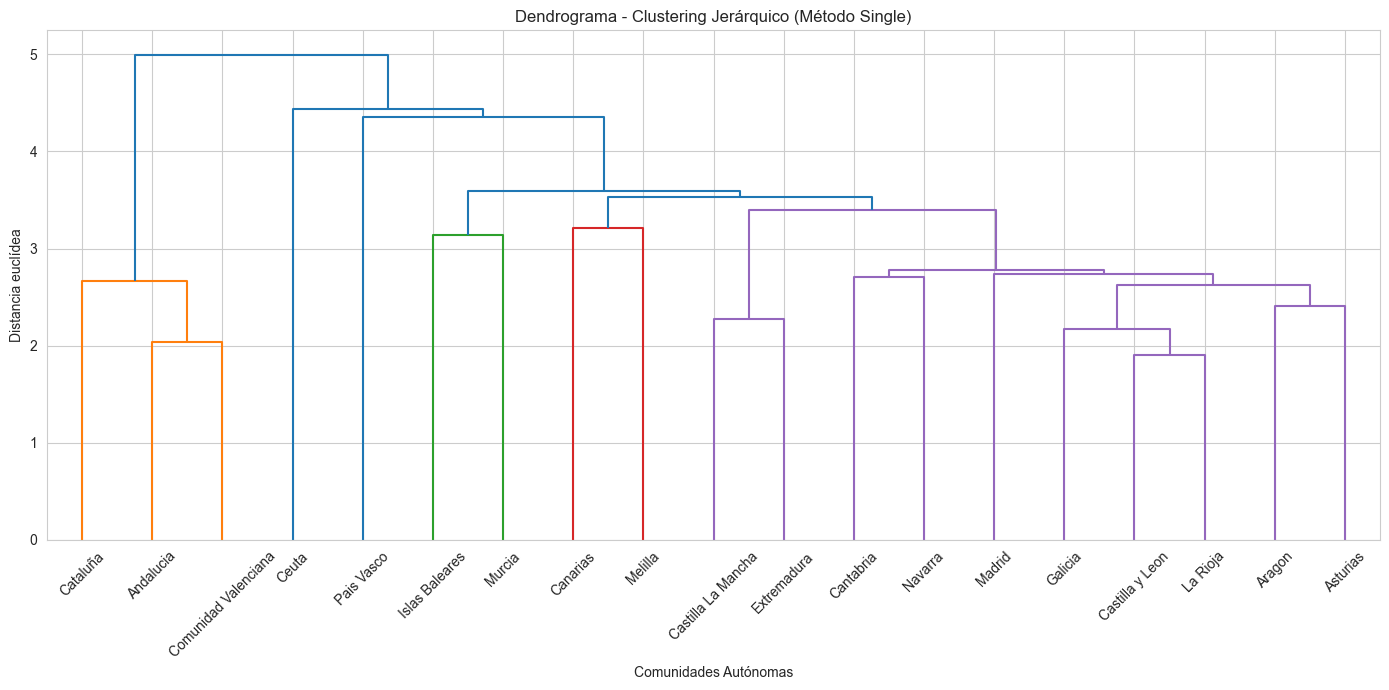

In [ ]:
# Para el modelo de clustering jerárquico hay que determinar la similitud entre los clusters usando métodos de enlace. Son tres: ward, complete o single. 
# Vamos a calcular cada uno y ver cuál es el que mejor encaja para nuestros datos. 
# 1. Método ward

M_ward = linkage(X_scaled, method="ward")

# Visualizamos el dendrograma con el método ward

plt.figure(figsize=(14, 7))

dendrogram(
    M_ward,
    labels=ccaa.values,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Dendrograma - Clustering Jerárquico (Método Ward)")
plt.xlabel("Comunidades Autónomas")
plt.ylabel("Distancia euclídea")
plt.tight_layout()
plt.show()

# 2. Método Complete

M_complete = linkage(X_scaled, method="complete")

# Visualizamos el dendrograma con el método complete

plt.figure(figsize=(14, 7))

dendrogram(
    M_complete,
    labels=ccaa.values,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Dendrograma - Clustering Jerárquico (Método Complete)")
plt.xlabel("Comunidades Autónomas")
plt.ylabel("Distancia euclídea")
plt.tight_layout()
plt.show()

# 3. Método Single

M_single = linkage(X_scaled, method="single")

# Visualizamos el dendrograma con el método single

plt.figure(figsize=(14, 7))

dendrogram(
    M_single,
    labels=ccaa.values,
    leaf_rotation=45,
    leaf_font_size=10
)

plt.title("Dendrograma - Clustering Jerárquico (Método Single)")
plt.xlabel("Comunidades Autónomas")
plt.ylabel("Distancia euclídea")
plt.tight_layout()
plt.show()

# Tras la visualización de los tres métodos hemos elegido Ward porque es el método jerárquico que mejor agrupa observaciones similares entre sí y genera clusters más compactos. 
# Además, es el más comparable con el modelo de K-Means.


# Modelo Final de Clustering Jerárquico - Método Ward

,ccaa,cluster_jerarquico
0,Andalucia,2
1,Aragon,0
2,Asturias,0
3,Canarias,1
4,Cantabria,0
5,Castilla La Mancha,3
6,Castilla y Leon,0
7,Cataluña,2
8,Ceuta,1
9,Comunidad Valenciana,2


cluster_jerarquico
0    9
1    3
2    3
3    4
Name: count, dtype: int64


,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita,cluster_kmeans
cluster_jerarquico,,,,,,,,,,,,,,,,
0,64.491660,35.508340,3577.222222,93.000000,93.311111,87.611111,95.577778,87.822222,62.487070,37.512930,67.081504,32.918496,68.670544,31.329456,15273.777778,1.0
1,69.890507,30.109493,2765.333333,95.366667,95.566667,82.033333,95.100000,82.466667,95.159980,4.840020,97.064080,2.935920,95.644891,4.355109,13150.666667,3.0
2,16.657098,83.342902,1503.333333,92.800000,93.233333,84.733333,95.366667,87.633333,87.769513,12.230487,65.652716,34.347284,63.202816,36.797184,13451.333333,0.0
3,71.550885,28.449115,7895.000000,90.925000,91.625000,84.600000,92.700000,85.525000,87.400028,12.599972,75.187820,24.812180,78.401202,21.598798,12182.250000,2.0


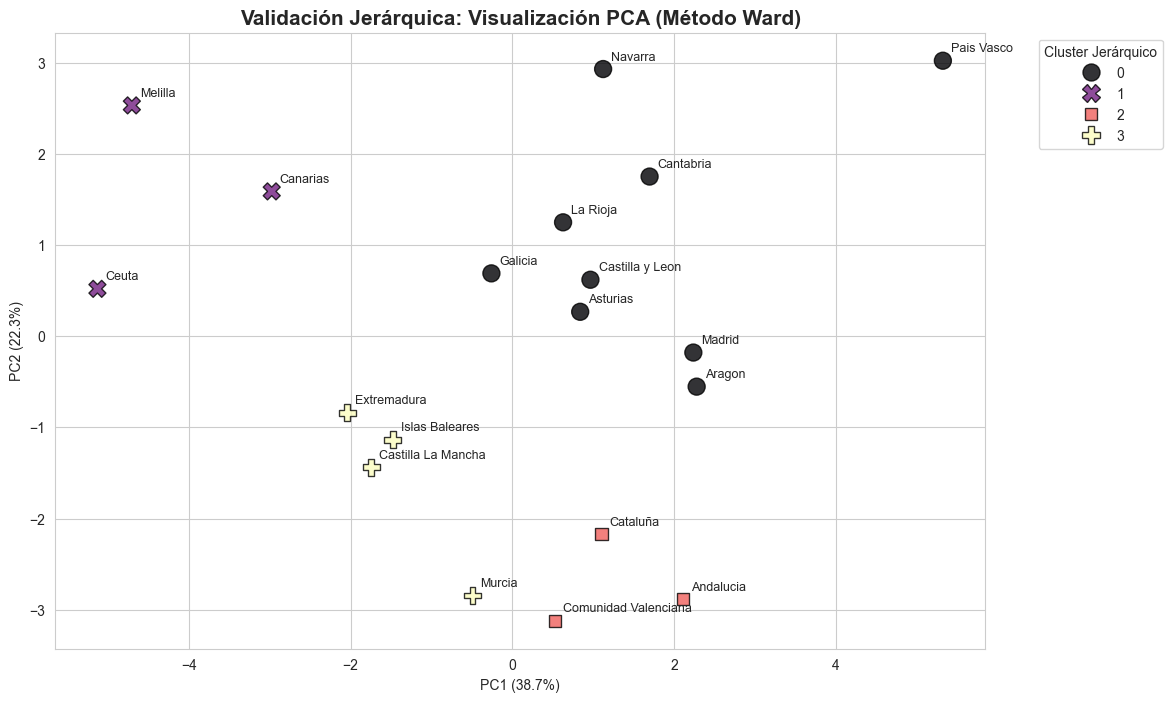

In [ ]:
# Entrenamos el modelo con nuestros datos

modelo_jerarquico = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

BaseFinal2["cluster_jerarquico"] = modelo_jerarquico.fit_predict(X_scaled)

# Visualizamos los resultados

display(BaseFinal2[["ccaa","cluster_jerarquico"]])

# Obtenemos el tamaño de los clusters jerárquicos para comprobar si los grupos están equilibrados

cluster_jerarquico_sizes = BaseFinal2["cluster_jerarquico"].value_counts().sort_index()
print(cluster_jerarquico_sizes)

# Calculamos las medias de las variables numéricas de cada cluster para identificar perfiles

cluster_jerarquico_summary = BaseFinal2.drop(columns=["ccaa"]).groupby("cluster_jerarquico").mean(numeric_only=True)
display(cluster_jerarquico_summary)

# Visualizamos el modelo gráficamente mediante PCA
# 1.Reducimos el modelo a dos dimensiones

pca_h = PCA(n_components=2)
X_pca_h = pca_h.fit_transform(X_scaled) 

# 2.Creamos un Dataframe para representar el modelo

df_pca_h = pd.DataFrame(X_pca_h, columns=["PC1", "PC2"])
df_pca_h["ccaa"] = BaseFinal2["ccaa"].values
df_pca_h["cluster"] = BaseFinal2["cluster_jerarquico"].values

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 3.Representamos el modelo gráficamente
scatter_h = sns.scatterplot(
    data=df_pca_h, x="PC1", y="PC2", hue="cluster", 
    palette="magma", s=150, style="cluster", edgecolor="black", alpha=0.8
)

for i in range(df_pca_h.shape[0]):
    plt.text(df_pca_h.PC1[i]+0.1, df_pca_h.PC2[i]+0.1, df_pca_h.ccaa[i], fontsize=9)

plt.title("Validación Jerárquica: Visualización PCA (Método Ward)", fontsize=15, fontweight='bold')
plt.xlabel(f"PC1 ({pca_h.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca_h.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster Jerárquico", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('graficos_clustering/06_pca_jerarquico_final.png', bbox_inches='tight', dpi=300)
plt.show()

# **Comparación de los modelos no supervisados: K-Means y Clustering Jerárquico**

## Carga de librerías

In [ ]:
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


Silhouette K-Means: 0.323
Silhouette Jerárquico: 0.323
Métricas de Calidad:
- Silhouette K-Means: 0.323
- Silhouette Jerárquico: 0.323

Métricas de Estabilidad (Concordancia):
- Adjusted Rand Index (ARI): 1.000 (Cercano a 1 es mejor)
- Normalized Mutual Info (NMI): 1.000


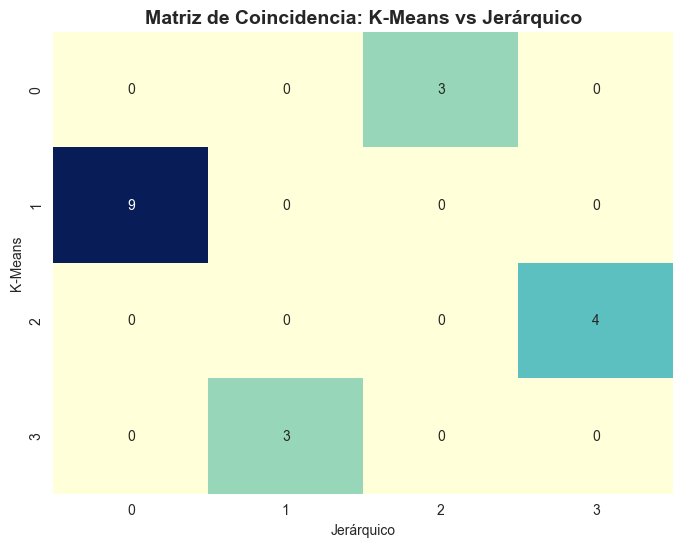

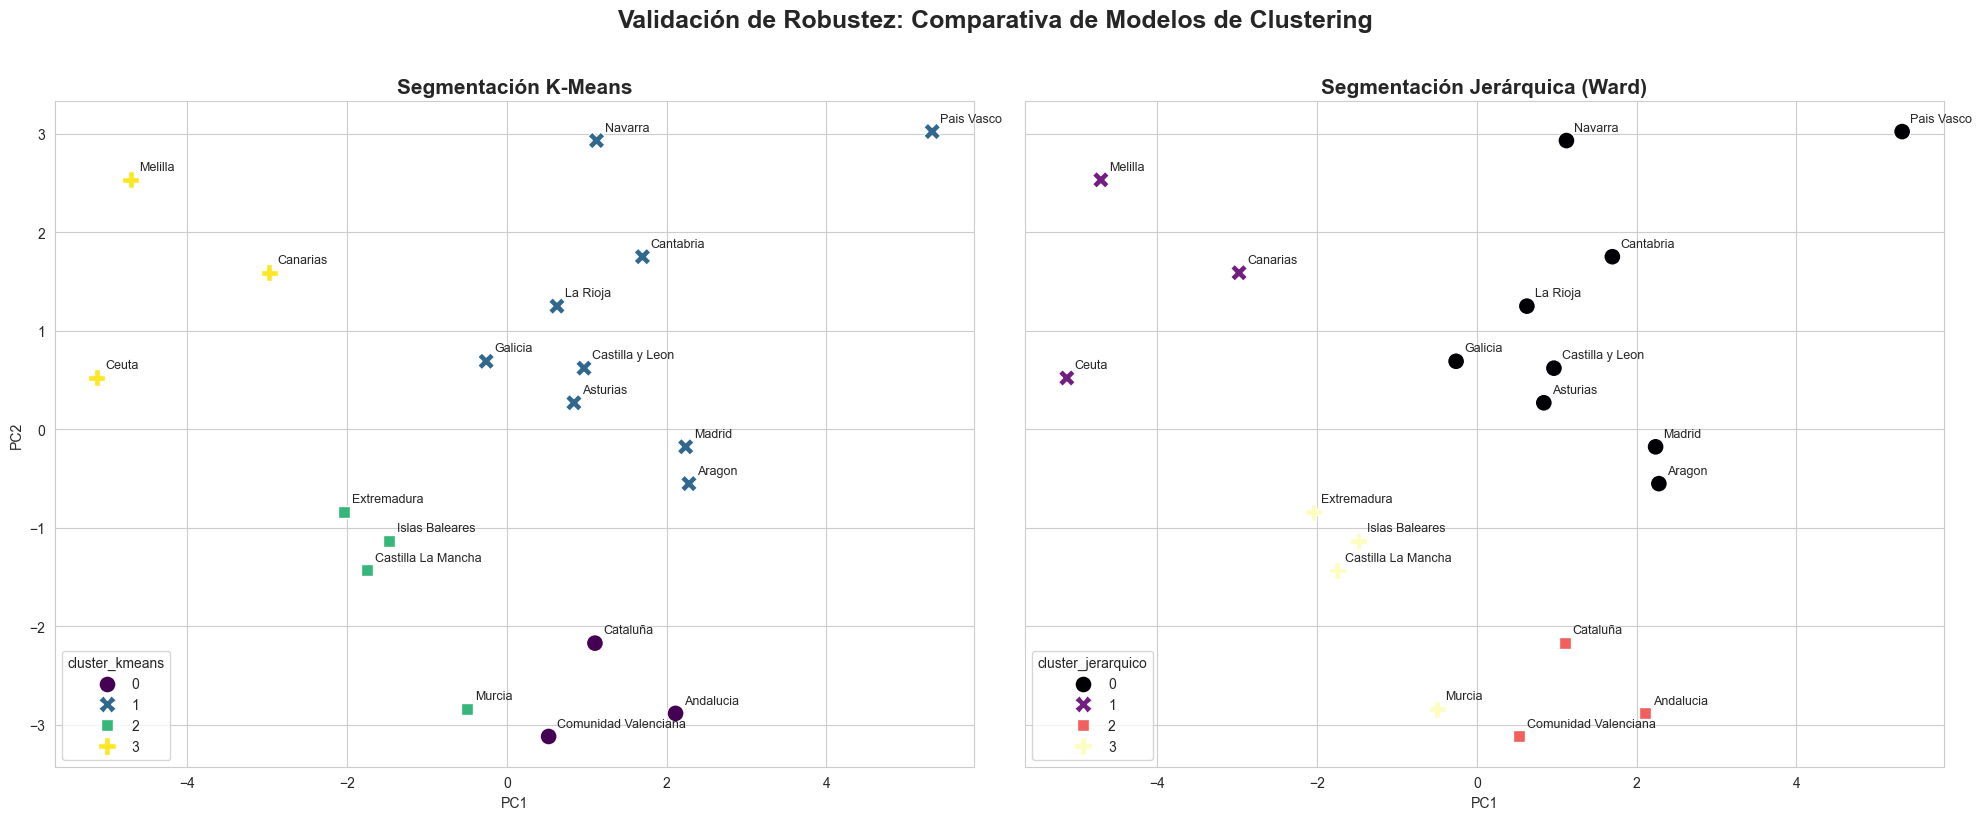

In [ ]:
# Calculamos de ambos modelos el coeficiente de Silhouette. Los estamos comparando de manera numérica.
# 1. Modelo K-Means

silhouette_kmeans = silhouette_score(X_scaled, BaseFinal2["cluster_kmeans"])
print("Silhouette K-Means:", round(silhouette_kmeans, 3))

# 2. Modelo Clustering Jerárquico

silhouette_jerarquico = silhouette_score(X_scaled, BaseFinal2["cluster_jerarquico"])
print("Silhouette Jerárquico:", round(silhouette_jerarquico, 3))

# Calculamos la concordancia entre modelos con las métricas de Índice de Rand Ajustado e Información Mutua Normalizada.

ari = adjusted_rand_score(BaseFinal2["cluster_kmeans"], BaseFinal2["cluster_jerarquico"])
nmi = normalized_mutual_info_score(BaseFinal2["cluster_kmeans"], BaseFinal2["cluster_jerarquico"])

# Obtenemos las métricas de calidad.

print(f"Métricas de Calidad:")
print(f"- Silhouette K-Means: {silhouette_kmeans:.3f}")
print(f"- Silhouette Jerárquico: {silhouette_jerarquico:.3f}")
print(f"\nMétricas de Estabilidad (Concordancia):")
print(f"- Adjusted Rand Index (ARI): {ari:.3f} (Cercano a 1 es mejor)")
print(f"- Normalized Mutual Info (NMI): {nmi:.3f}")

# Visualizamos la matriz de confusión para analizar las coincidencias entre ambos.

tabla = pd.crosstab(BaseFinal2["cluster_kmeans"], 
                    BaseFinal2["cluster_jerarquico"],
                    colnames=['Jerárquico'], rownames=['K-Means'])

plt.figure(figsize=(8,6))
sns.heatmap(tabla, annot=True, cmap="YlGnBu", fmt="d", cbar=False)
plt.title("Matriz de Coincidencia: K-Means vs Jerárquico", fontsize=14, fontweight='bold')
plt.savefig('graficos_clustering/07_matriz_coincidencia.png', dpi=300)
plt.show()

# Visualizamos una matriz de comparación de PCA de ambos modelos. 

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# 1. Gráfico K-Means

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=BaseFinal2["cluster_kmeans"], 
                palette='viridis', s=150, ax=axes[0], style=BaseFinal2["cluster_kmeans"])
for i, txt in enumerate(BaseFinal2["ccaa"]):
    axes[0].annotate(txt, (X_pca[i,0]+0.1, X_pca[i,1]+0.1), fontsize=9)
axes[0].set_title("Segmentación K-Means", fontsize=15, fontweight='bold')
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# 2. Gráfico Jerárquico

sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=BaseFinal2["cluster_jerarquico"], 
                palette='magma', s=150, ax=axes[1], style=BaseFinal2["cluster_jerarquico"])
for i, txt in enumerate(BaseFinal2["ccaa"]):
    axes[1].annotate(txt, (X_pca[i,0]+0.1, X_pca[i,1]+0.1), fontsize=9)
axes[1].set_title("Segmentación Jerárquica (Ward)", fontsize=15, fontweight='bold')
axes[1].set_xlabel("PC1")

plt.suptitle("Validación de Robustez: Comparativa de Modelos de Clustering", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos_clustering/08_comparativa_pca_modelos.png', bbox_inches='tight', dpi=300)
plt.show()

